# Business Trajectory — Growing, Shrinking, or Seasonal?

Follow-up to `Q1`–`Q4`, which all segment customers at a single point in time (by spend, by
loyalty, by shipping status). None of them ask whether the underlying business itself is
stable — if the business is growing fast, shrinking, or highly seasonal, that changes how much
weight those point-in-time findings should carry going forward.

**Setup:** the dataset spans Oct 2018 to Oct 2020. This notebook asks three things:
1. Is the business growing, flat, or declining over that window — and is the growth coming
   from more customers, bigger baskets, or both?
2. Is there a seasonal pattern (e.g. a holiday spike) independent of the overall trend?
3. Is customer behavior itself changing over time — are newer cohorts becoming repeat buyers
   at a different rate than older ones (a stability check on `Q4_loyal_customers.ipynb`)?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

plt.rcParams["axes.formatter.useoffset"] = False
plt.rcParams["axes.formatter.limits"] = (-999, 999)

PLAIN = mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}")
PCT = mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}%")
MILLIONS = mticker.FuncFormatter(lambda x, pos: f"{x/1e6:,.0f}")

df = pd.read_csv("orders.csv", parse_dates=["Order_Date"])
df = df.sort_values(["Customer_iD", "Order_Date"])
print("Date range:", df["Order_Date"].min().date(), "to", df["Order_Date"].max().date())
df.shape

Date range: 2018-10-14 to 2020-10-30


(682792, 11)

## 1. Monthly orders, revenue, and profit

Resample to monthly totals. Two data-quality caveats to flag before reading the trend:
- **Oct 2018 is a partial month** — the data starts 2018-10-14, so it undercounts a full month.
- **Profit and Profit_margin are entirely missing (NaN) for Oct–Dec 2018** (16,200 orders,
  ~2.4% of the dataset). Revenue and order counts are fine for that period, but any profit
  trend has to start Jan 2019 or it will show a misleading drop to zero at the start.

In [2]:
monthly = df.set_index("Order_Date").resample("MS").agg(
    orders=("Order_ID", "size"),
    revenue=("Total_amount_excl__VAT", "sum"),
    profit=("Profit", "sum"),
)
monthly["aov"] = monthly["revenue"] / monthly["orders"]

missing_profit = df["Profit"].isna().groupby(df["Order_Date"].dt.to_period("M")).mean()
print("Share of orders with missing Profit, by month (first 4 shown):")
print(missing_profit.head(4))

monthly.round(2)

Share of orders with missing Profit, by month (first 4 shown):
Order_Date
2018-10    1.000000
2018-11    1.000000
2018-12    1.000000
2019-01    0.052267
Freq: M, Name: Profit, dtype: float64


,orders,revenue,profit,aov
Order_Date,,,,
2018-10-01,1179,547260.57,0.00,464.17
2018-11-01,7301,3177738.56,0.00,435.25
2018-12-01,7720,3223921.39,0.00,417.61
2019-01-01,12857,5353931.09,3516920.95,416.42
2019-02-01,14566,6342175.88,4267142.04,435.41
2019-03-01,15937,7187011.57,4953815.34,450.96
2019-04-01,12791,5761256.09,3763657.67,450.41
2019-05-01,12634,5894280.14,4116995.05,466.54
2019-06-01,9966,4752906.14,3285077.43,476.91


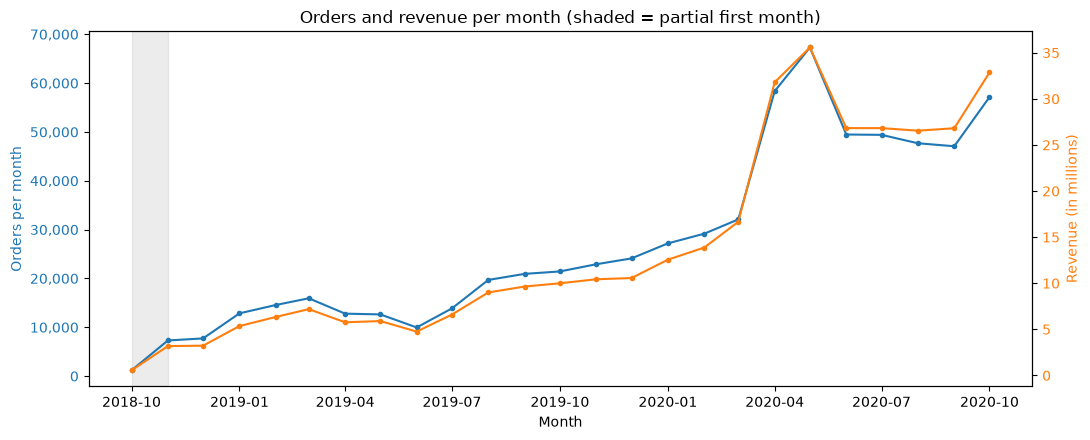

In [3]:
fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(monthly.index, monthly["orders"], color="tab:blue", marker="o", markersize=3, label="Orders")
ax1.set_ylabel("Orders per month", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.yaxis.set_major_formatter(PLAIN)
ax1.set_xlabel("Month")
ax1.axvspan(monthly.index.min(), pd.Timestamp("2018-11-01"), color="gray", alpha=0.15)

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["revenue"], color="tab:orange", marker="o", markersize=3, label="Revenue")
ax2.set_ylabel("Revenue (in millions)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
ax2.yaxis.set_major_formatter(MILLIONS)

ax1.set_title("Orders and revenue per month (shaded = partial first month)")
fig.tight_layout()
plt.show()

**Conflict:** this is not a flat or seasonal-only business — it's growing, and not smoothly.
Orders climb steadily through 2019, then roughly **double** between March and April 2020
(32,096 → 58,365 orders) and stay elevated for the rest of the window. That's a step-change,
not a gentle trend, and it lands right at the early-2020 COVID online-shopping shift — plausible
given the timing, though the data has no channel/marketing field to confirm the cause directly.

## 1b. Growth rates — week-over-week and quarter-over-quarter

The monthly view above smooths over shorter-term dynamics. Two finer cuts: WoW growth (noisy,
but flags acceleration/deceleration inside a month) and QoQ growth (smoother, good for reading
the headline trajectory in fewer points).

**Caveats before reading either:** the first calendar week (2018-10-14 to 10-21, only 2 days of
data) and the last (2020-10-27 to 11-02, only 4 days, since the dataset ends 2020-10-30) are
partial stubs — comparing into/out of them produces meaningless swings (the raw series has a
+2,586% "growth" week from this alone), so both are dropped before computing WoW %. Similarly,
Q4 2020 (Oct only — one month of a three-month quarter) is a partial quarter and will show an
artificial drop in QoQ terms; read it as "not comparable," not as a real reversal.

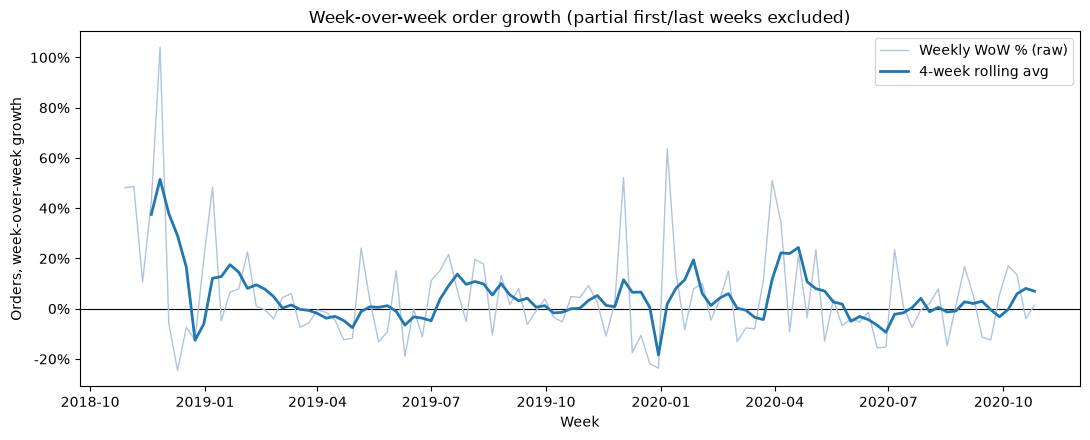

Mean WoW growth: 5.0%, std: 19.7pp, n=105 weeks


In [4]:
weekly = df.set_index("Order_Date").resample("W-MON").agg(
    orders=("Order_ID", "size"),
    revenue=("Total_amount_excl__VAT", "sum"),
)
weekly = weekly.iloc[1:-1]  # drop partial first/last week stubs (data starts 2018-10-14, ends 2020-10-30)
weekly["orders_wow_%"] = weekly["orders"].pct_change() * 100
weekly["orders_wow_4wk_avg_%"] = weekly["orders_wow_%"].rolling(4).mean()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.axhline(0, color="black", linewidth=0.8)
ax.plot(weekly.index, weekly["orders_wow_%"], color="lightsteelblue", linewidth=1, label="Weekly WoW % (raw)")
ax.plot(weekly.index, weekly["orders_wow_4wk_avg_%"], color="tab:blue", linewidth=2, label="4-week rolling avg")
ax.yaxis.set_major_formatter(PCT)
ax.set_ylabel("Orders, week-over-week growth")
ax.set_xlabel("Week")
ax.set_title("Week-over-week order growth (partial first/last weeks excluded)")
ax.legend()
fig.tight_layout()
plt.show()

print(f"Mean WoW growth: {weekly['orders_wow_%'].mean():.1f}%, std: {weekly['orders_wow_%'].std():.1f}pp, n={weekly['orders_wow_%'].count()} weeks")

WoW growth averages **+5.0%** but is noisy (±20pp week to week, as expected at weekly
granularity) — the raw line alone isn't readable, which is why the 4-week rolling average is
plotted on top. That rolling average stays positive almost throughout, with two visible dips:
a soft patch around mid-2019 (matching the Apr–Jun trough already seen in Section 1) and a
cooling-off after the Apr–May 2020 surge peaks. No new contradiction with Section 1 — this is
the same trend at a noisier resolution.

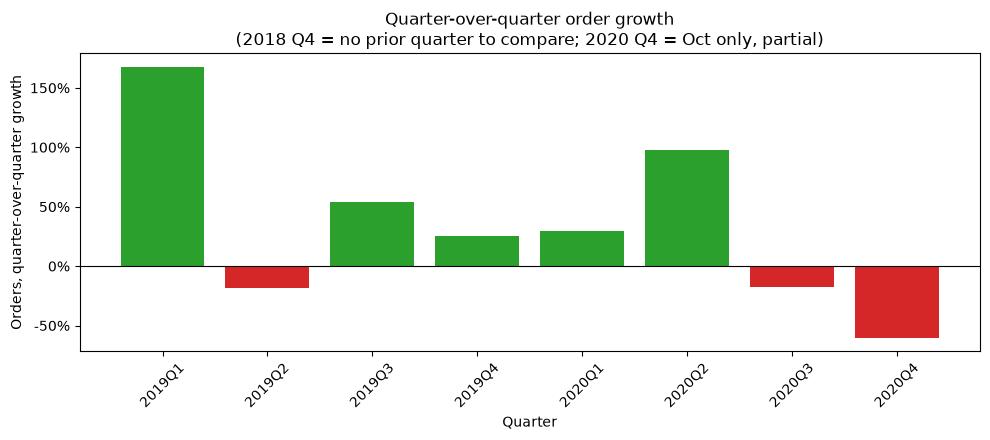

,orders,revenue,orders_qoq_%,revenue_qoq_%
Order_Date,,,,
2018-10-01,16200,6948920.52,NaN,NaN
2019-01-01,43360,18883118.54,167.65,171.74
2019-04-01,35391,16408442.37,-18.38,-13.11
2019-07-01,54503,25237939.65,54.00,53.81
2019-10-01,68448,30978693.20,25.59,22.75
2020-01-01,88444,43085510.95,29.21,39.08
2020-04-01,175139,94188788.61,98.02,118.61
2020-07-01,144166,80175421.59,-17.68,-14.88
2020-10-01,57141,32857915.06,-60.36,-59.02


In [5]:
quarterly = df.set_index("Order_Date").resample("QS").agg(
    orders=("Order_ID", "size"),
    revenue=("Total_amount_excl__VAT", "sum"),
)
quarterly["orders_qoq_%"] = quarterly["orders"].pct_change() * 100
quarterly["revenue_qoq_%"] = quarterly["revenue"].pct_change() * 100
quarter_labels = quarterly.index.to_series().dt.to_period("Q").astype(str)

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ["tab:red" if v < 0 else "tab:green" for v in quarterly["orders_qoq_%"].fillna(0)]
ax.bar(quarter_labels, quarterly["orders_qoq_%"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.yaxis.set_major_formatter(PCT)
ax.set_ylabel("Orders, quarter-over-quarter growth")
ax.set_xlabel("Quarter")
ax.set_title("Quarter-over-quarter order growth\n(2018 Q4 = no prior quarter to compare; 2020 Q4 = Oct only, partial)")
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

quarterly.round(2)

QoQ growth is positive in every full quarter except two: **2019 Q2 (-18.4% orders)**, the
mid-2019 dip already visible in Section 1's monthly chart (driven by a weak June), and
**2020 Q3 (-17.7%)**, cooling off after the surge. The standout is **2020 Q2 at +98.0% orders /
+118.6% revenue** — the April step-change from Section 1 landing squarely inside one quarter.
**2020 Q4 shows -60.4%**, but that's the partial-quarter artifact flagged above, not a real
reversal: it's one month (Oct, 57,141 orders) being compared to a full three-month quarter —
Oct 2020 alone is still higher than any single month of 2020 Q3.

## 2. Where is the growth coming from — more customers, or bigger baskets?

Two candidate explanations for the step-change: (a) more new customers are showing up, or
(b) existing customers are ordering bigger baskets. Check both: new customers acquired per
month (by first order date), and average order value (AOV) per month.

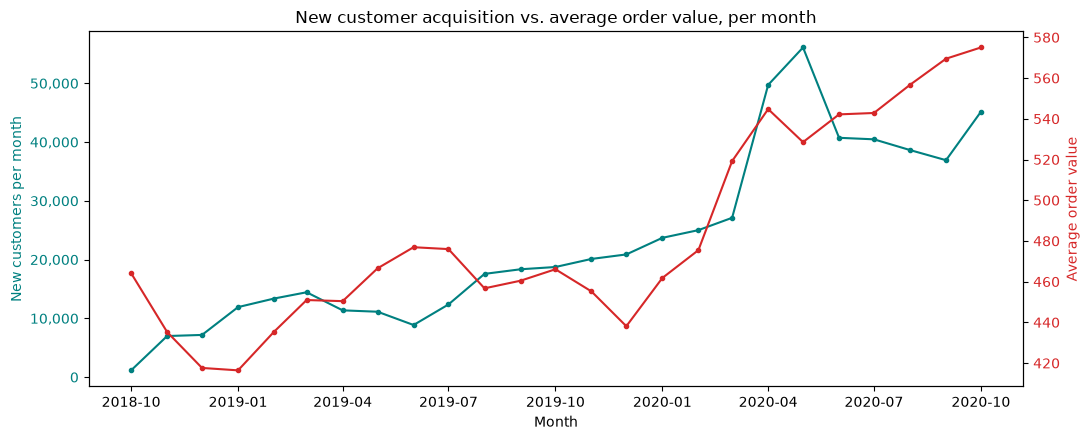

New customers as % of that month's orders (last 6 months):
Order_Date
2020-05-01    83.3
2020-06-01    82.3
2020-07-01    81.9
2020-08-01    81.0
2020-09-01    78.4
2020-10-01    79.0
Freq: MS, dtype: float64


In [6]:
first_order = df.groupby("Customer_iD")["Order_Date"].min()
new_customers = first_order.dt.to_period("M").value_counts().sort_index()
new_customers.index = new_customers.index.to_timestamp()

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(new_customers.index, new_customers.values, color="teal", marker="o", markersize=3, label="New customers")
ax1.set_ylabel("New customers per month", color="teal")
ax1.tick_params(axis="y", labelcolor="teal")
ax1.yaxis.set_major_formatter(PLAIN)
ax1.set_xlabel("Month")

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["aov"], color="tab:red", marker="o", markersize=3, label="AOV")
ax2.set_ylabel("Average order value", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.yaxis.set_major_formatter(PLAIN)

ax1.set_title("New customer acquisition vs. average order value, per month")
fig.tight_layout()
plt.show()

pct_new = (new_customers / monthly["orders"]).round(3) * 100
print("New customers as % of that month's orders (last 6 months):")
print(pct_new.tail(6).round(1))

**Both.** New customer acquisition nearly doubles the same month orders do (27,111 → 49,722
new customers, March → April 2020), so the step-change is mostly a wave of new customers, not
existing ones ordering more often. But AOV is trending up across the *entire* window too —
from ~416 in Jan 2019 to ~575 by Oct 2020, a steady ~38% rise independent of the April 2020
jump. So growth has two separate drivers stacked on top of each other: a gradual, sustained
rise in basket size, plus a sudden acquisition surge in April 2020.

## 3. Is there real seasonality, or just trend?

With only one full calendar year (2019) in the data, seasonality can't be cleanly separated
from the underlying growth trend — but it's worth looking at 2019's month-by-month share of
that year's orders to see the shape.

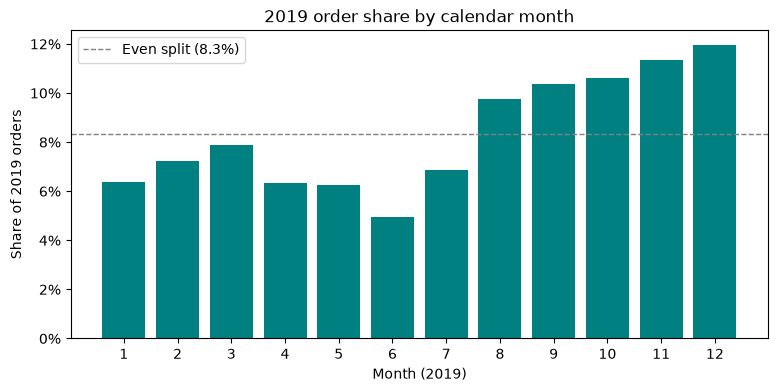

,orders,revenue,orders_share_%
Order_Date,,,
1,12857,5353931.09,6.37
2,14566,6342175.88,7.22
3,15937,7187011.57,7.90
4,12791,5761256.09,6.34
5,12634,5894280.14,6.26
6,9966,4752906.14,4.94
7,13867,6600470.13,6.87
8,19699,8996842.42,9.77
9,20937,9640627.10,10.38


In [7]:
y2019 = df[df["Order_Date"].dt.year == 2019]
month_shape = y2019.groupby(y2019["Order_Date"].dt.month).agg(
    orders=("Order_ID", "size"), revenue=("Total_amount_excl__VAT", "sum")
)
month_shape["orders_share_%"] = (month_shape["orders"] / month_shape["orders"].sum() * 100).round(2)
even_split = 100 / 12

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(month_shape.index, month_shape["orders_share_%"], color="teal")
ax.axhline(even_split, color="gray", linestyle="--", linewidth=1, label=f"Even split ({even_split:.1f}%)")
ax.set_xticks(range(1, 13))
ax.set_xlabel("Month (2019)")
ax.set_ylabel("Share of 2019 orders")
ax.yaxis.set_major_formatter(PCT)
ax.set_title("2019 order share by calendar month")
ax.legend()
plt.show()

month_shape

**Caveat, not a conclusion:** 2019 shows a June trough (4.9% share, lowest of the year) and a
Nov–Dec peak (11.4%, 11.9%) consistent with a typical holiday-shopping bump — but 2019 was also
a year of continuous underlying growth (Section 1), so a monotonically rising business will
*always* show its highest months late in the year even with zero real seasonality. One full
year isn't enough to tell the two apart with confidence. **Don't treat Nov/Dec as a reliable
seasonal spike for planning purposes without at least one more full year to confirm the pattern
repeats independent of overall growth.**

## 3b. Does the Aug–Dec elevation repeat across years?

Section 3 flagged that 2019's Nov/Dec peak can't be distinguished from ordinary growth with
only one full year in hand. The dataset gives partial views of two more years — Oct-Dec 2018
(the business's first ~2.5 months) and Jan-Oct 2020 (the COVID growth surge, no Nov/Dec) — so
overlapping months can be compared, but not innocently: raw order counts always favor 2020
(the biggest year) and disfavor 2018 (the smallest, still ramping up), because the whole
business was growing throughout. A cleaner test is month-over-month growth *within* each
year: does the pace of growth itself pick up heading into August, independent of how big that
year is overall?

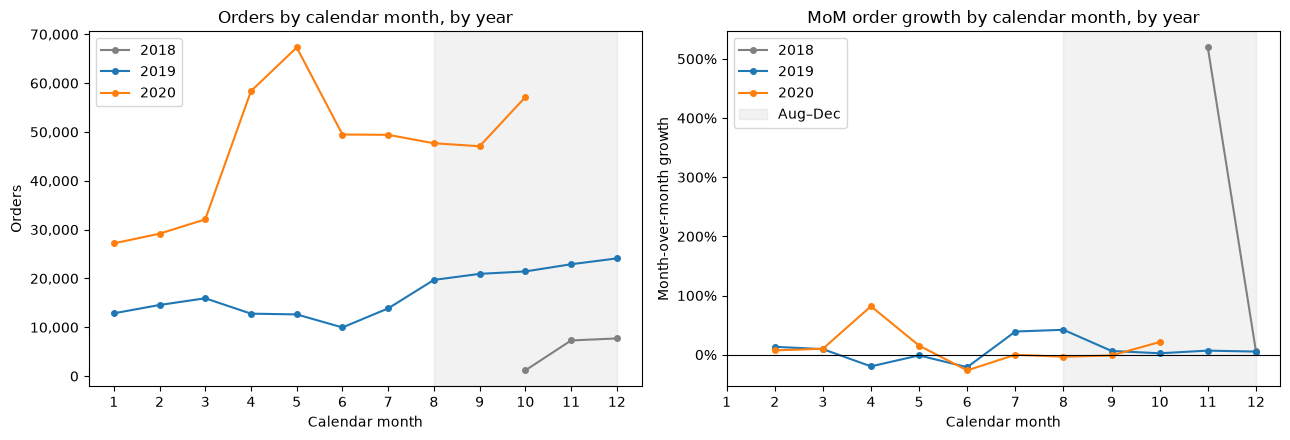

Order_Date,2018,2019,2020
Order_Date,,,
1,NaN,NaN,NaN
2,NaN,13.3,7.3
3,NaN,9.4,10.0
4,NaN,-19.7,81.8
5,NaN,-1.2,15.3
6,NaN,-21.1,-26.5
7,NaN,39.1,-0.1
8,NaN,42.1,-3.5
9,NaN,6.3,-1.3


In [8]:
by_year_month = df.groupby([df["Order_Date"].dt.year, df["Order_Date"].dt.month]).size()
by_year_month = by_year_month.unstack(0)
mom_by_year = by_year_month.pct_change() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
colors = {2018: "gray", 2019: "tab:blue", 2020: "tab:orange"}

for year in by_year_month.columns:
    ax1.plot(by_year_month.index, by_year_month[year], marker="o", markersize=4,
              color=colors[year], label=str(year))
ax1.axvspan(8, 12, color="gray", alpha=0.1)
ax1.set_xticks(range(1, 13))
ax1.set_xlabel("Calendar month")
ax1.set_ylabel("Orders")
ax1.yaxis.set_major_formatter(PLAIN)
ax1.set_title("Orders by calendar month, by year")
ax1.legend()

for year in mom_by_year.columns:
    ax2.plot(mom_by_year.index, mom_by_year[year], marker="o", markersize=4,
              color=colors[year], label=str(year))
ax2.axhline(0, color="black", linewidth=0.8)
ax2.axvspan(8, 12, color="gray", alpha=0.1, label="Aug–Dec")
ax2.set_xticks(range(1, 13))
ax2.set_xlabel("Calendar month")
ax2.set_ylabel("Month-over-month growth")
ax2.yaxis.set_major_formatter(PCT)
ax2.set_title("MoM order growth by calendar month, by year")
ax2.legend()

fig.tight_layout()
plt.show()

mom_by_year.round(1)

**Doesn't clearly repeat — and where it's actually testable, 2020 argues against it.** 2018 has
no Aug/Sep data at all (starts Oct 14), so the only real cross-year test is 2019 vs. 2020 for
Aug–Oct:
- **2019:** growth *accelerates* heading into Aug — Jul MoM +39.1%, Aug MoM +42.1%, the two
  biggest jumps of the year — then holds a slower positive pace through Sep–Dec (+2% to +7%
  MoM). This is the pattern that made Aug–Dec look elevated.
- **2020:** the same Aug/Sep months are flat-to-slightly-negative (Aug -3.5%, Sep -1.3%) — no
  echo of 2019's jump. 2020's real acceleration happened earlier and far more sharply, in
  Apr–May (the COVID surge from Sections 1–2), and by Aug–Oct growth had already cooled to
  roughly flat.

So the Jul/Aug inflection that produced 2019's Nov/Dec highs doesn't show up in 2020's Jul/Aug.
This reinforces Section 3's existing caveat rather than resolving it: **2019's Aug–Dec
elevation looks like the shape of one growing year, not a calendar-driven effect that
recurs.** Nov/Dec themselves remain completely untested outside 2019 — 2018 doesn't reach back
to Aug/Sep and 2020 doesn't reach forward to Nov/Dec — so a genuine holiday-season claim still
needs a second full November–December to confirm or rule out.

## 4. Is customer behavior itself stable? (stability check on `Q4_loyal_customers.ipynb`)

`Q4` found only 14.2% of customers ever place a 2nd order, across the whole dataset. If that
number is being pulled down by a big, still-immature 2020 cohort that simply hasn't had time to
reorder yet, the "true" repeat rate could be understated — or if newer, COVID-driven customers
are lower-intent one-off buyers, it could be overstated for the future. Check by cohort: for
customers grouped by the month of their *first* order, what % reorder within a fixed 90-day
window? Using a fixed window (rather than "ever") makes cohorts comparable regardless of how
much total observation time they've had — only cohorts with at least 90 days between their
first order and the dataset's last date (2020-10-30) are included, so the most recent 2 months
of cohorts (Sep–Oct 2020) are dropped for not having had a fair chance to repeat yet.

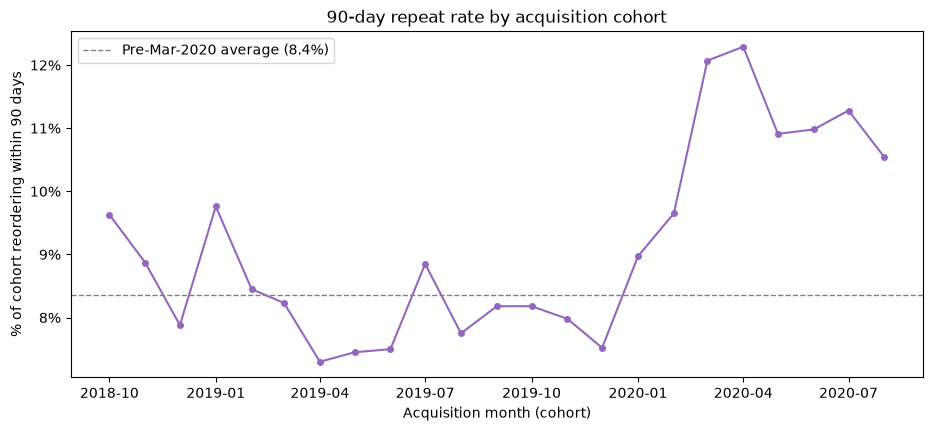

cohort
2018-10-01     9.63
2018-11-01     8.87
2018-12-01     7.88
2019-01-01     9.76
2019-02-01     8.45
2019-03-01     8.23
2019-04-01     7.30
2019-05-01     7.45
2019-06-01     7.50
2019-07-01     8.85
2019-08-01     7.75
2019-09-01     8.18
2019-10-01     8.18
2019-11-01     7.98
2019-12-01     7.52
2020-01-01     8.97
2020-02-01     9.65
2020-03-01    12.07
2020-04-01    12.29
2020-05-01    10.91
2020-06-01    10.98
2020-07-01    11.28
2020-08-01    10.54
Freq: MS, Name: repeat_within_90d, dtype: float64

In [9]:
cust = df.groupby("Customer_iD").agg(n_orders=("Order_ID", "size"), first_order=("Order_Date", "min"))
second_order = df.groupby("Customer_iD")["Order_Date"].apply(lambda s: s.iloc[1] if len(s) >= 2 else pd.NaT)
cust["second_order"] = second_order
cust["days_to_2nd"] = (cust["second_order"] - cust["first_order"]).dt.days
cust["repeat_within_90d"] = cust["days_to_2nd"] <= 90

max_date = df["Order_Date"].max()
cust["cohort"] = cust["first_order"].dt.to_period("M")
cust["obs_days"] = (max_date - cust["cohort"].dt.to_timestamp()).dt.days
eligible = cust[cust["obs_days"] >= 90]

cohort_rate = (eligible.groupby("cohort")["repeat_within_90d"].mean() * 100).round(2)
cohort_rate.index = cohort_rate.index.to_timestamp()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(cohort_rate.index, cohort_rate.values, color="tab:purple", marker="o", markersize=4)
ax.axhline(cohort_rate.loc[:"2020-02-01"].mean(), color="gray", linestyle="--", linewidth=1,
           label=f"Pre-Mar-2020 average ({cohort_rate.loc[:'2020-02-01'].mean():.1f}%)")
ax.set_ylabel("% of cohort reordering within 90 days")
ax.yaxis.set_major_formatter(PCT)
ax.set_xlabel("Acquisition month (cohort)")
ax.set_title("90-day repeat rate by acquisition cohort")
ax.legend()
plt.show()

cohort_rate

**Resolution — is `Q4`'s loyalty finding stale?** No, if anything it's understated for where
the business is now. Cohorts acquired Oct 2018–Feb 2020 hover in a tight 7.3–9.8% range for
90-day repeat rate. Starting with the March 2020 cohort — the same month the acquisition surge
begins — the rate jumps to a consistently higher 10.5–12.3% band and stays there through the
last eligible cohort (Aug 2020). The wave of new customers driving 2020's growth isn't
lower-quality, one-off traffic; **they're repeating at a noticeably higher rate than the
customers acquired before them.** `Q4`'s 14.2%-ever-repeat figure blends all cohorts together,
so it likely understates the repeat rate of the business's current customer base.

## Summary

**Setup:** every prior notebook (`Q1`–`Q4`) segments customers at a single point in time. This
one asks whether the business generating those customers is itself stable, growing, or
seasonal — because a fast-moving business puts a shelf life on point-in-time conclusions.

**Conflict / findings:**
- **The business roughly tripled** over the two-year window (169,711 orders / 76.9M revenue in
  the first full 12 months vs. 454,761 orders / 238.4M in the second — +168% orders, +210%
  revenue, +219% profit YoY), driven by a sharp step-change starting **April 2020** where
  monthly orders roughly doubled and stayed elevated.
- That step-change is **mostly new customer acquisition** (new customers per month nearly
  doubled the same month), stacked on top of a **separate, gradual AOV increase** (~416 → ~575,
  +38%) that runs across the entire window, not just the 2020 surge.
- **Seasonality can't be confirmed** with confidence — 2019 shows a plausible Nov/Dec
  holiday-shaped bump, but one full calendar year can't be distinguished from ordinary
  month-over-month growth. Needs a second full year to verify before using it for planning
  (e.g. inventory/staffing).
- **Data quality note:** Profit/Profit_margin are fully missing for Oct–Dec 2018 (~2.4% of
  orders) — any profit trend or full-history profit total should account for this rather than
  reading it as a real dip to zero.
- **Newer customer cohorts are repeating *more*, not less** — the 90-day repeat rate rises from
  a steady ~7-10% (cohorts through Feb 2020) to ~10.5-12.3% (cohorts from Mar 2020 on),
  right as the growth surge begins. This directly de-risks `Q4_loyal_customers.ipynb`'s
  headline number: the 14.2% ever-repeat rate is a blend across cohorts and likely
  *understates* the repeat behavior of the business's current, larger customer base.

**Resolution:**
- Treat `Q1`–`Q4`'s findings as describing a business that is actively growing and, on the
  loyalty dimension, *improving* — not a static snapshot. The HV/spend-concentration and
  free-shipping mechanics are unlikely to have changed shape, but their scale has grown
  substantially and should be re-benchmarked periodically rather than assumed fixed.
- Investigate what changed operationally around March/April 2020 (marketing spend, channel mix,
  a promotion) — whatever drove the acquisition surge is also, so far, bringing in customers
  who stick around better than before, which is worth deliberately reinforcing rather than
  treating as a one-off pandemic blip.
- Revisit the Nov/Dec "seasonality" question once a second full year of data is available
  before committing to holiday-specific inventory or staffing decisions.